In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/ubuntu22/4761-project/src")

from spatial_mrf.model_HMRF import AW_HMRF

import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad    



In [2]:
# processed and downloaded adata in MERFISH.ipynb
adata=sc.read_h5ad("/home/ubuntu22/4761-project/data/adata_sub.h5ad")

In [ ]:
adata.obs.head()

,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id,ccf_parcellation_index,parcellation_index,parcellation_division,parcellation_structure,parcellation_substructure
cell_label,,,,,,,,,,,,,,,,,,
108940785382162732493708293637850319612,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,14939,5.788414,1.028376,6.757411,0.999919,0.534859,True,5dc4ac95-e277-48d2-9490-775c2c95c3fe,432.0,432,Isocortex,RSPd,RSPd1
110121453980283886359371770138534031651,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5255,5.799457,0.936812,6.757411,0.999965,0.898492,True,96a06e08-4b5c-49aa-9e64-6e1637d80320,432.0,432,Isocortex,RSPd,RSPd1
110681941776910416996005993916230046940,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5249,5.731140,0.989278,6.757411,0.995081,0.521716,True,47650dfa-8c4d-49e5-b46e-1eef44c259e9,0.0,0,unassigned,unassigned,unassigned
112216418487705663967407444725523177005,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5252,5.725126,1.005335,6.757411,0.958629,0.921491,True,1b88e7ed-9a89-4932-bcc5-5e77a8e32109,432.0,432,Isocortex,RSPd,RSPd1
119348955776260385935648650386184853504,Zhuang-ABCA-1.080,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,5267,5.770379,0.937048,6.757411,0.997261,0.566163,True,ed6c455e-af83-4d06-b38e-dc2fcfd6e9e5,432.0,432,Isocortex,RSPd,RSPd1


In [3]:
""" #build physical edges based on spatial coordinates and weight them by anatomical boundaries.
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix


k_neighbors = 8
alpha_penalty = 0.2

# Build the spatial graph using native MERFISH coordinates
spatial_coords = adata.obsm['spatial'][:, :2]
knn_model = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='ball_tree').fit(spatial_coords)
distances, indices = knn_model.kneighbors(spatial_coords)


ccf_label_column = 'ccf_parcellation_index'

print(f"Using anatomy labels from: {ccf_label_column}")
anatomy_labels = adata.obs[ccf_label_column].values

# Validate that anatomy labels are not all NaN
if pd.isna(anatomy_labels).all():
    raise ValueError(f"All values in {ccf_label_column} are NaN. CCF alignment may have failed.")

rows = []
cols = []
weights = []

# Construct the Anatomy-Weighted Adjacency Matrix
for i in range(len(indices)):
    for j_idx in range(1, k_neighbors+1):
        neighbor_i = indices[i, j_idx]
        
        rows.append(i)
        cols.append(neighbor_i)

        # AW Logic: Check if physical neighbors belong to the same official brain region
        # Handle NaN values gracefully
        if pd.isna(anatomy_labels[i]) or pd.isna(anatomy_labels[neighbor_i]):
            weights.append(alpha_penalty)  # Use penalty for unknown regions
        elif anatomy_labels[i] == anatomy_labels[neighbor_i]:
            weights.append(1.0)
        else:
            weights.append(alpha_penalty)

W_aw = csr_matrix((weights, (rows, cols)), shape=(len(spatial_coords), len(spatial_coords)))

print(f"AW-Adjacency Matrix built.")
print(f"Matrix shape: {W_aw.shape}, Non-zero edges: {W_aw.nnz}")
 """

' #build physical edges based on spatial coordinates and weight them by anatomical boundaries.\nfrom sklearn.neighbors import NearestNeighbors\nfrom scipy.sparse import csr_matrix\n\n\nk_neighbors = 8\nalpha_penalty = 0.2\n\n# Build the spatial graph using native MERFISH coordinates\nspatial_coords = adata.obsm[\'spatial\'][:, :2]\nknn_model = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm=\'ball_tree\').fit(spatial_coords)\ndistances, indices = knn_model.kneighbors(spatial_coords)\n\n\nccf_label_column = \'ccf_parcellation_index\'\n\nprint(f"Using anatomy labels from: {ccf_label_column}")\nanatomy_labels = adata.obs[ccf_label_column].values\n\n# Validate that anatomy labels are not all NaN\nif pd.isna(anatomy_labels).all():\n    raise ValueError(f"All values in {ccf_label_column} are NaN. CCF alignment may have failed.")\n\nrows = []\ncols = []\nweights = []\n\n# Construct the Anatomy-Weighted Adjacency Matrix\nfor i in range(len(indices)):\n    for j_idx in range(1, k_neighbor

In [ ]:
from spatial_mrf.utils import build_anatomy_weighted_knn_graph
W_aw = build_anatomy_weighted_knn_graph(
    adata,
    coord_key="spatial",
    label_key="parcellation_division",
    k=8,
    alpha=0.2,
)


AW graph built successfully
shape: (36636, 36636) nnz: 341978


In [4]:
embedding_pca = adata.obsm['X_pca']

In [5]:
from spatial_mrf.model_HMRF import AW_HMRF

betas = [8.0, 15.0, 20.0, 25.0, 30.0]

results = {}

for beta in betas:
    model = AW_HMRF(
        n_regions=15,
        beta=beta,
        max_em_iter=10,
        max_icm_iter=5,
    )

    res = model.fit(embedding_pca, W_aw)
    results[float(beta)] = res

    print(f"beta={beta} done")

beta=8.0 done
beta=15.0 done
beta=20.0 done
beta=25.0 done
beta=30.0 done


--- Visualizing Convergence for Beta = 8.0 ---


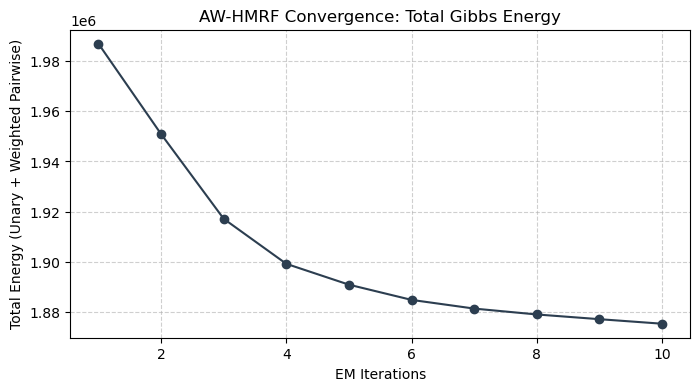

--- Visualizing Convergence for Beta = 15.0 ---


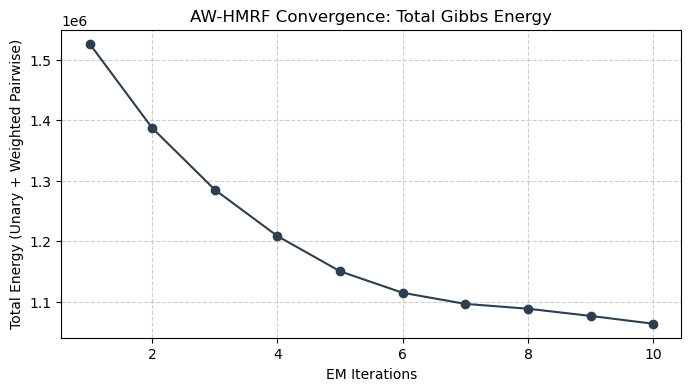

--- Visualizing Convergence for Beta = 20.0 ---


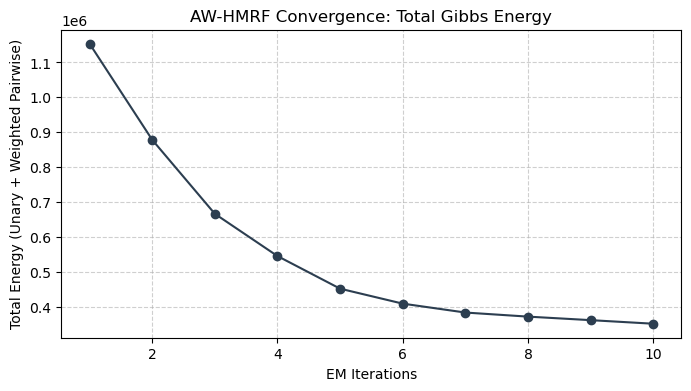

--- Visualizing Convergence for Beta = 25.0 ---


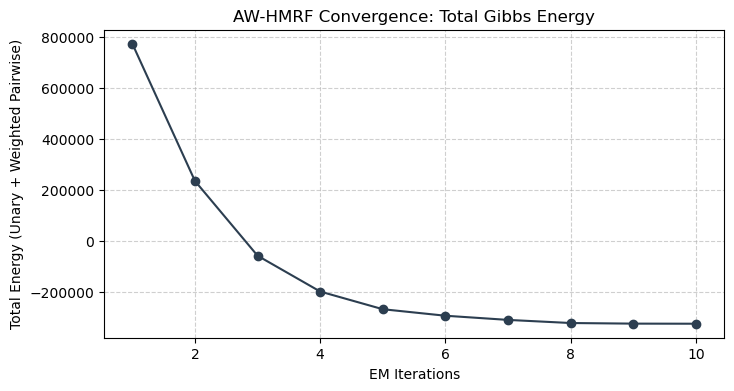

--- Visualizing Convergence for Beta = 30.0 ---


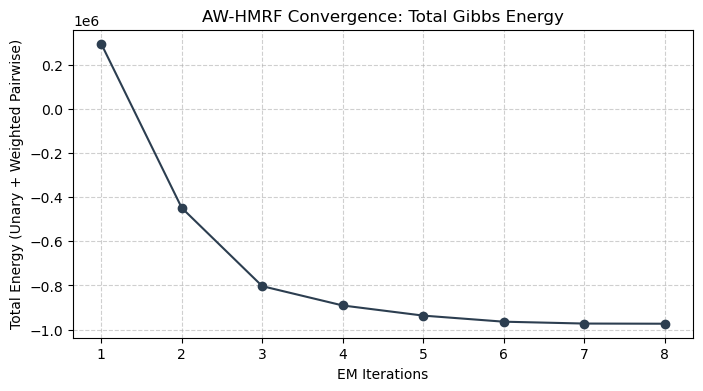

In [ ]:
# energy history evaluation
from spatial_mrf.evaluation import plot_energy_history
for beta, res in results.items():
    print(f"--- Visualizing Convergence for Beta = {beta} ---")
    plot_energy_history(res) 

The Gibbs Energy convergence plots confirm the numerical stability of our AW-HMRF framework. Regardless of the $\beta$ value, the model consistently reaches an energy plateau within 10 iterations, indicating that the ICM solver efficiently navigates the complex landscape formed by the anatomical priors and the transcriptomic embeddings of 37,068 cells.

/tmp/ipykernel_24582/738236984.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


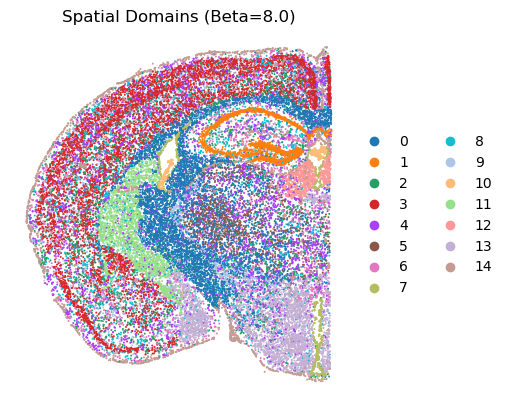

/tmp/ipykernel_24582/738236984.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


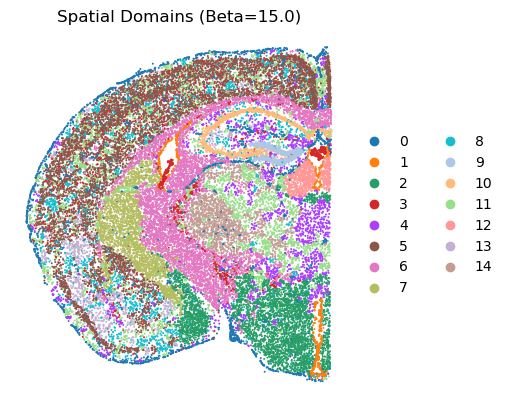

/tmp/ipykernel_24582/738236984.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


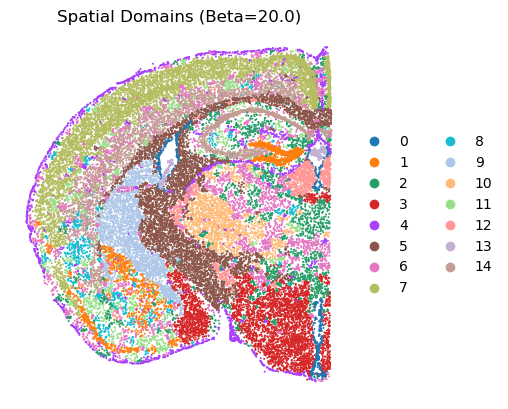

/tmp/ipykernel_24582/738236984.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


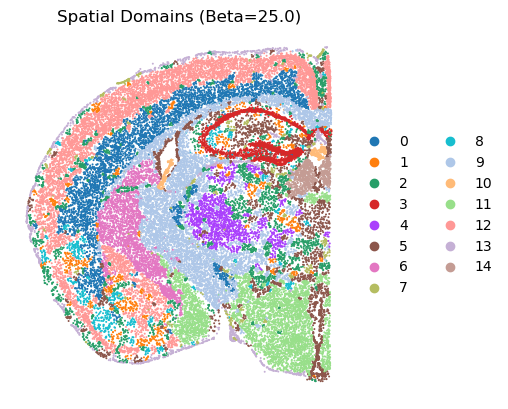

/tmp/ipykernel_24582/738236984.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


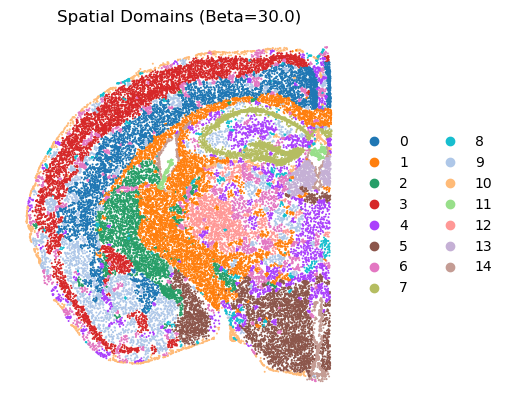

In [ ]:
# visulization of HMRF results on spatial coordinates
import matplotlib.pyplot as plt
import scanpy as sc

# adata with spatial coordinates and HMRF results
for beta, res in results.items():
    col_name = f'AW_HMRF_beta_{beta}'
    adata.obs[col_name] = pd.Categorical(res.states)
    
    sc.pl.spatial(
        adata, 
        color=[col_name], 
        title=f"Spatial Domains (Beta={beta})",
        spot_size=0.034, # 37068 cells
        frameon=False
    )

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

ref_categories = adata.obs['parcellation_division'].unique()

cmap = plt.get_cmap('tab20')
colors = [plt.cm.colors.to_hex(cmap(i % 20)) for i in range(len(ref_categories))]

color_map = dict(zip(ref_categories, colors))

#adata.uns[f'{"ccf_parcellation_index"}_colors'] = colors   
adata.uns[f'{"parcellation_division"}_colors'] = colors

Plotting beta=8.0


/home/ubuntu22/4761-project/src/spatial_mrf/utils.py:256: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


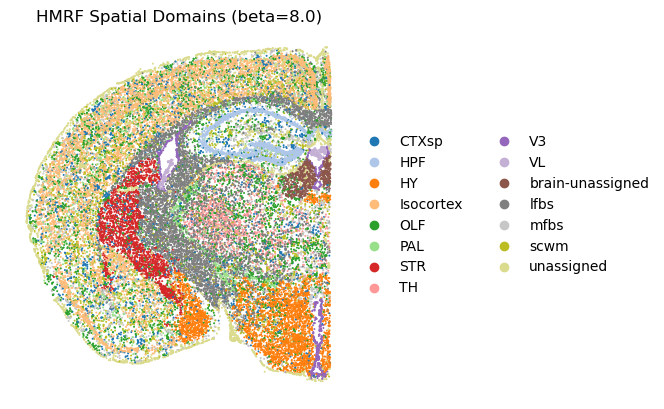

Plotting beta=15.0


/home/ubuntu22/4761-project/src/spatial_mrf/utils.py:256: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


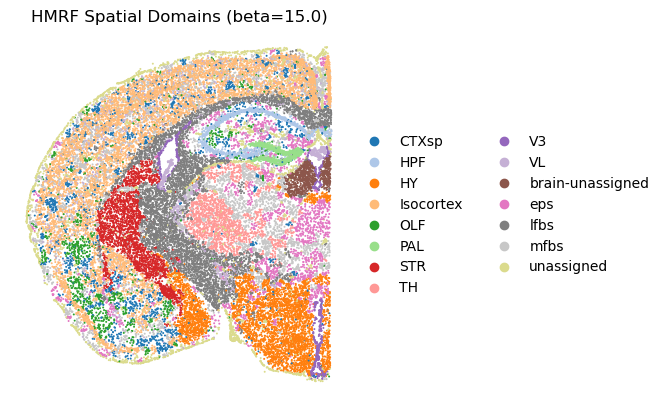

Plotting beta=20.0


/home/ubuntu22/4761-project/src/spatial_mrf/utils.py:256: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


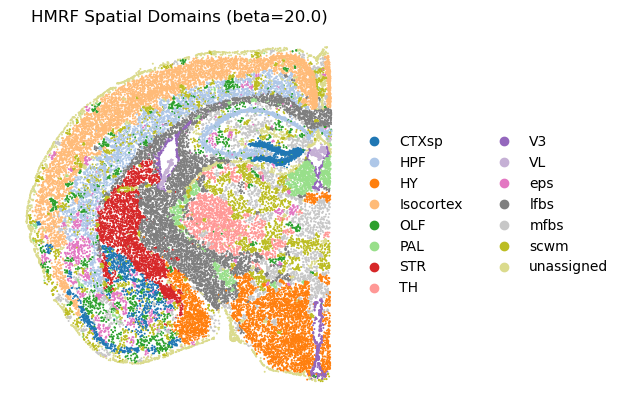

Plotting beta=25.0


/home/ubuntu22/4761-project/src/spatial_mrf/utils.py:256: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


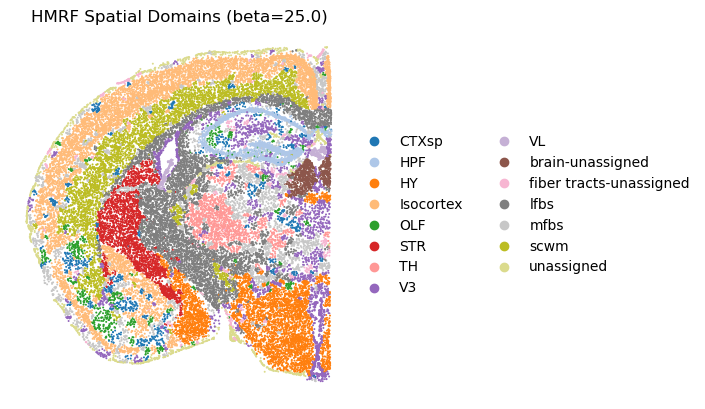

Plotting beta=30.0


/home/ubuntu22/4761-project/src/spatial_mrf/utils.py:256: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


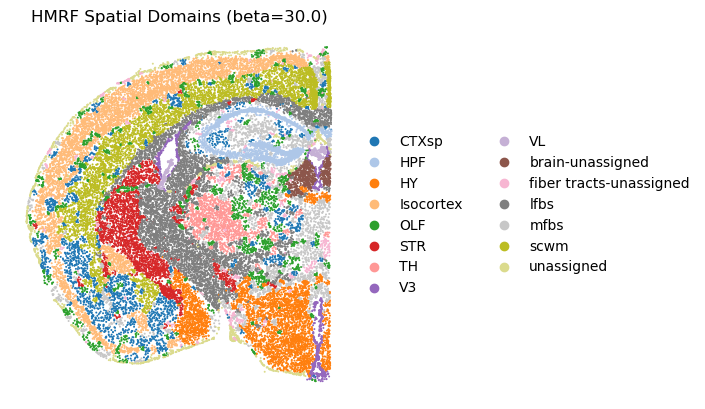

In [ ]:
from spatial_mrf.utils import plot_hmrf_spatial_results
plot_hmrf_spatial_results(
    adata,
    results,
    label_key="parcellation_division",
    spot_size=0.034
)

In [ ]:
from spatial_mrf.evaluation import evaluate_all, print_results

results_eval = {}

for beta in betas:
    res = evaluate_all(
        adata,
        label_key="parcellation_division",
        pred_key=f"AW_HMRF_beta_{beta}_named",
        embedding_key="X_pca",
        W=W_aw
    )

    results_eval[beta] = res
    print(f"\n===== beta={beta} =====")
    print_results(res)

/home/ubuntu22/4761-project/src/spatial_mrf/metrics.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  same += np.sum(labels[neighbors] == labels[i])



===== beta=8.0 =====

=== Evaluation Results ===
ARI: 0.2389
NMI: 0.3642
purity: 0.5491
homogeneity: 0.3808
completeness: 0.3490
silhouette: 0.1428
spatial_consistency: 0.5552


/home/ubuntu22/4761-project/src/spatial_mrf/metrics.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  same += np.sum(labels[neighbors] == labels[i])



===== beta=15.0 =====

=== Evaluation Results ===
ARI: 0.3243
NMI: 0.4380
purity: 0.6044
homogeneity: 0.4563
completeness: 0.4212
silhouette: 0.0654
spatial_consistency: 0.7532


/home/ubuntu22/4761-project/src/spatial_mrf/metrics.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  same += np.sum(labels[neighbors] == labels[i])



===== beta=20.0 =====

=== Evaluation Results ===
ARI: 0.3222
NMI: 0.4502
purity: 0.5993
homogeneity: 0.4733
completeness: 0.4292
silhouette: 0.0426
spatial_consistency: 0.8491


/home/ubuntu22/4761-project/src/spatial_mrf/metrics.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  same += np.sum(labels[neighbors] == labels[i])



===== beta=25.0 =====

=== Evaluation Results ===
ARI: 0.3220
NMI: 0.4557
purity: 0.6072
homogeneity: 0.4713
completeness: 0.4410
silhouette: 0.0512
spatial_consistency: 0.8889


/home/ubuntu22/4761-project/src/spatial_mrf/metrics.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  same += np.sum(labels[neighbors] == labels[i])



===== beta=30.0 =====

=== Evaluation Results ===
ARI: 0.3051
NMI: 0.4605
purity: 0.6078
homogeneity: 0.4817
completeness: 0.4411
silhouette: 0.0447
spatial_consistency: 0.8909


<Axes: >

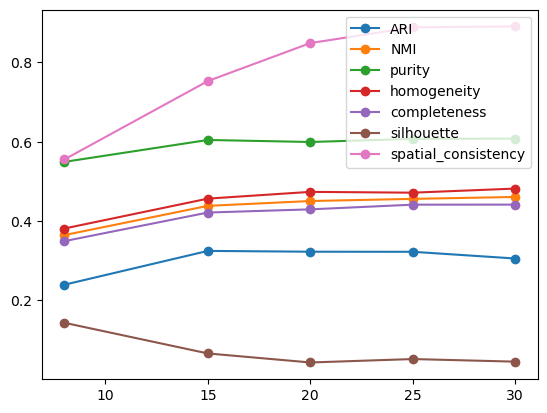

In [ ]:
import pandas as pd

df = pd.DataFrame(results_eval).T
df.plot(marker="o")

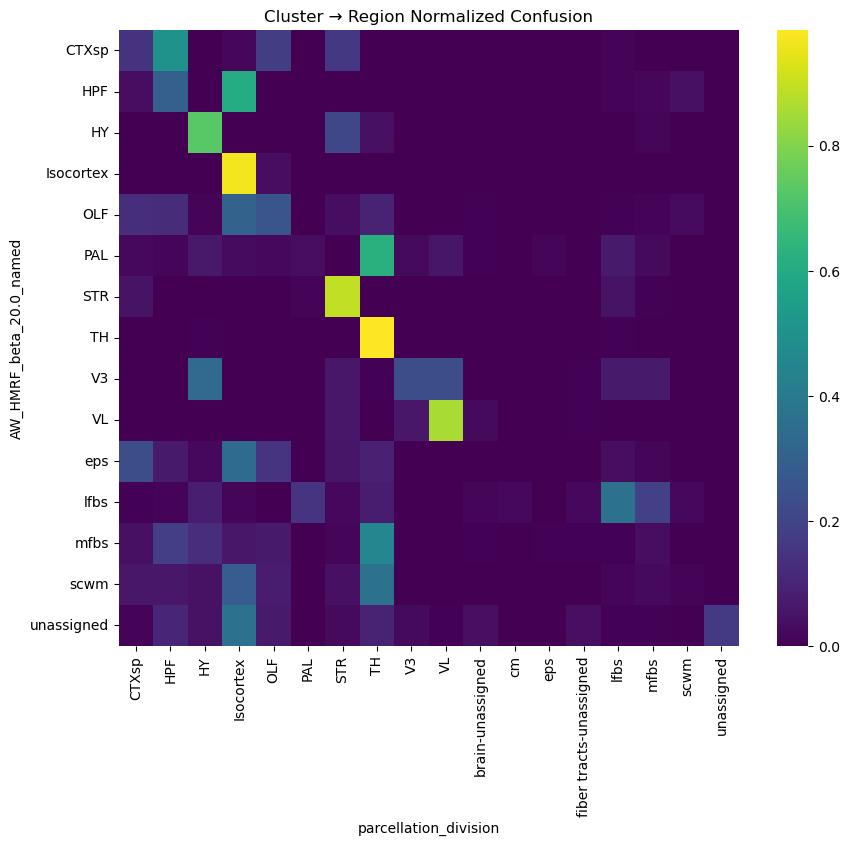

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. build table
tab = pd.crosstab(
    adata.obs['AW_HMRF_beta_20.0_named'],
    adata.obs['parcellation_division']
)

# 2. normalize (cluster → region)
tab_norm = tab.div(tab.sum(axis=1), axis=0)

# 3. plot
plt.figure(figsize=(10, 8))
sns.heatmap(tab_norm, cmap="viridis")
plt.title("Cluster → Region Normalized Confusion")
plt.show()

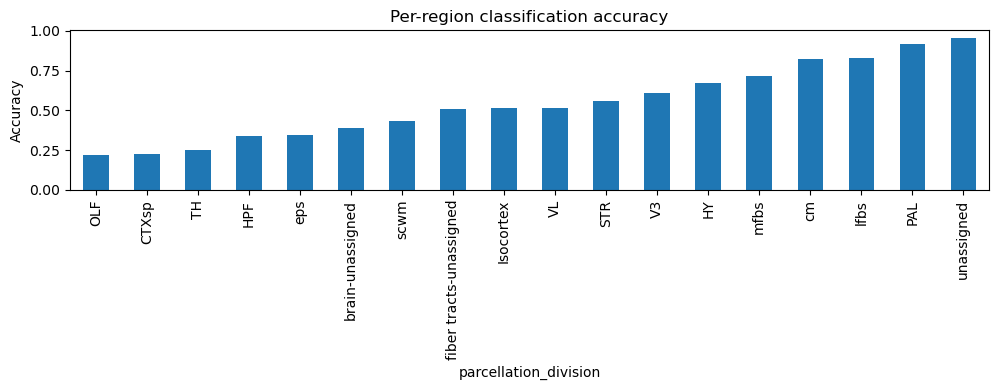

In [ ]:
per_region_acc = tab.max(axis=0) / tab.sum(axis=0)

# sort + plot
per_region_acc.sort_values().plot(kind="bar", figsize=(10,4))
plt.ylabel("Accuracy")
plt.title("Per-region classification accuracy")
plt.tight_layout()
plt.show()

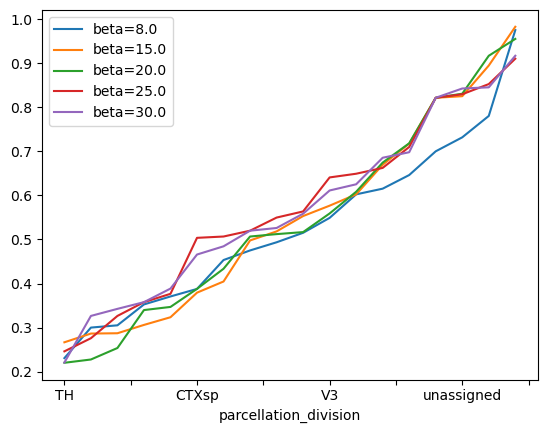

In [ ]:
for beta in betas:
    tab = pd.crosstab(
        adata.obs[f'AW_HMRF_beta_{beta}_named'],
        adata.obs['parcellation_division']
    )

    per_region_acc = tab.max(axis=0) / tab.sum(axis=0)

    per_region_acc.sort_values().plot(label=f"beta={beta}")

plt.legend()
plt.show()